In [62]:
# ensures that if we change something in .core, it sees it imediately without having to restart the kernel
# every time you run a cell, all imported modules are reloaded auomatically
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import scipy
from kneed import KneeLocator
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import time

# Our package
import neuro_lib as nl

# SETTING SEED FOR REPRODUCIBILITY
np.random.seed(0)


# Data with temporal structure
In the previous section, we evaluated different Mutual Information estimators (KDE, binning, Gaussian, and Gaussian Copula) on i.i.d. variables with known functional dependencies (linear, quadratic, and non-linear transformations). This allowed us to assess their ability to capture static dependencies under controlled conditions.

We now extend the analysis to the temporal domain, where dependencies are directional and evolve over time. In this context, Transfer Entropy (TE) provides a natural generalization of MI, enabling the detection of directed information flow between time series.

## Transfer Entropy
Transfer Entropy ($TE$) is a directional measure of information transfer. It quantifies how much the uncertainty of the future of a target signal $Y$ is reduced by knowing the past of a source signal $X$, beyond what is already explained by the past of $Y$ itself. Formally, for a source $X$ and target $Y$ with a coupling lag $\ell$ and embedding dimension $m$:$$TE_{X \to Y}(\ell) = I(Y_t ; X_{t-\ell} \mid Y^{(m)}_{t-1})$$Using the chain rule of information, this Conditional Mutual Information can be decomposed into the difference of two Shannon Entropies:$$TE_{X \to Y}(\ell) = H(Y_t \mid Y^{(m)}_{t-1}) - H(Y_t \mid Y^{(m)}_{t-1}, X_{t-\ell})$$

#### Relationship with MI Estimators
One of the core strengths of our neuro_lib is its modularity. We do not implement new mathematical engines for Transfer Entropy; instead, we reuse our Mutual Information (MI) Estimators by reformulating TE as a sum of MI terms.For any stationary process, TE can be expressed as:$$TE_{X \to Y}(\ell) = I(X_{t-\ell} ; [Y_t, Y^{(m)}_{t-1}]) - I(X_{t-\ell} ; Y^{(m)}_{t-1})$$ This allows us to leverage the four estimators already implemented in estimators.py. 

#### Directedness Index ($DI$)
To distinguish between true causality and simple correlation, we compute the Directedness Index:$$DI = TE_{X \to Y} - TE_{Y \to X}$$ 

- $DI > 0$: Information flows predominantly from $X$ to $Y$.
- $DI \approx 0$: The relationship is either non-existent or purely symmetric (correlation).

To systematically evaluate the performance of TE estimators, we generate synthetic time series with known ground-truth causal structure. This allows us to benchmark the estimators under controlled settings before applying them to real neural data.


### Simulated time series

Linear System: Autoregressive (AR) Processes

We generate coupled autoregressive processes to model linear interactions with a known directional structure. A typical formulation is:

\begin{aligned}
X_t &= \alpha X_{t-1} + \epsilon_t^X \\
Y_t &= \beta Y_{t-1} + \gamma X_{t-\ell} + \epsilon_t^Y
\end{aligned}

where:
*	$\alpha, \beta$ control the persistence of each process,
*	$\gamma$ determines the coupling strength from X to Y,
*	$\ell$ is the true interaction lag,
*	$\epsilon_t^X, \epsilon_t^Y$ are Gaussian noise terms.

This setup defines a clear ground-truth direction of information flow ($X \rightarrow Y$), making it ideal for validating whether TE correctly identifies both direction and lag.


Simulated data provides full access to the ground-truth generative mechanism, including the direction of information flow (X → Y), the interaction lag (ℓ), and the coupling strength, all defined a priori during data generation.

This enables a systematic validation of Transfer Entropy estimators by assessing whether they correctly recover:
*	the direction of information transfer,
*	the true interaction lag,
*	and the sensitivity of estimates with respect to known reference values.

The goal is not to obtain an exact analytical value of Transfer Entropy (which is generally intractable in nonlinear systems), but to evaluate the consistency of different estimators with the known causal structure.

The simulation framework also allows controlled stress testing by varying:
*	Signal-to-Noise Ratio (SNR), to assess robustness to noise,
*	sample size (N), to analyze finite-sample bias and variance,
*	coupling strength, to evaluate sensitivity to interaction intensity.

This controlled setting enables a reproducible and systematic comparison of estimation methods under progressively more challenging conditions.

In [64]:
# Generate artificial time series
N = 5000
alpha=beta=gamma=0.5
sigma_x=sigma_y=0.1
(x,y) = nl.generate_ar_coupled(N, alpha, beta, gamma, 5, sigma_x, sigma_y)

### Pre-analysis and Parameter Selection

Before computing Transfer Entropy, standard preprocessing steps are applied:
*	Stationarity check (ADF test): verifies that the time series has stable statistical properties over time, a requirement for reliable inference.

Augmented Dickey-Fuller (ADF) Test. To ensure the stability of our information measures, we test for stationarity. The ADF test checks for a unit root in the signal by fitting the following regression:$$\Delta y_t = \alpha + \delta y_{t-1} + \sum_{i=1}^{p} \beta_i \Delta y_{t-i} + \epsilon_t$$Null Hypothesis ($H_0$): $\delta = 0$ (The process has a unit root and is non-stationary). Success Criterion: A $p$-value $< 0.05$ allows us to reject $H_0$, confirming the signal is stationary and suitable for TE analysis.

*	Embedding delay (τ, first minimum of MI): identifies the time lag that best reduces redundancy between embedded components.

Average Mutual Information (AMI)To determine the optimal embedding delay ($\tau$), we calculate the Mutual Information between a signal and its lagged version across a range of delays.$$I(Y_t ; Y_{t-\tau}) = \sum_{y_t, y_{t-\tau}} P(y_t, y_{t-\tau}) \log_2 \frac{P(y_t, y_{t-\tau})}{P(y_t)P(y_{t-\tau})}$$ Selection Criterion: We select $\tau$ at the first local minimum of the AMI curve. This ensures that the components of our embedded vector are sufficiently independent, maximizing the information content of the reconstructed state space.

*	Embedding dimension (m, FNN method): determines the minimum state-space dimension needed to unfold the underlying dynamics without self-overlaps.

To find the minimum embedding dimension ($m$), we analyze how the proximity of points changes as we increase the dimensionality of the phase space.Let $R_m^2(t)$ be the distance between a point and its nearest neighbor in $m$ dimensions. After moving to $m+1$ dimensions, the new distance is $R_{m+1}^2(t)$. A neighbor is declared false if:$$\sqrt{\frac{R_{m+1}^2(t) - R_m^2(t)}{R_m^2(t)}} > R_{tol}$$Selection Criterion: We choose the smallest $m$ such that the percentage of False Nearest Neighbors drops below a predefined threshold (typically $1\%$). This indicates that the attractor is fully "unfolded" and self-intersections are resolved.

These steps ensure that the reconstructed state space is appropriate for TE estimation and comparable across methods.


Checking AR:
  [OK] Source (X) is stationary (p-value: 0.0000e+00)
  > Source (X) Optimal Delay: 6
  > Target (Y) Optimal Delay: 9
  [Note] Large discrepancy in Tau between X and Y. Consider using separate embeddings.


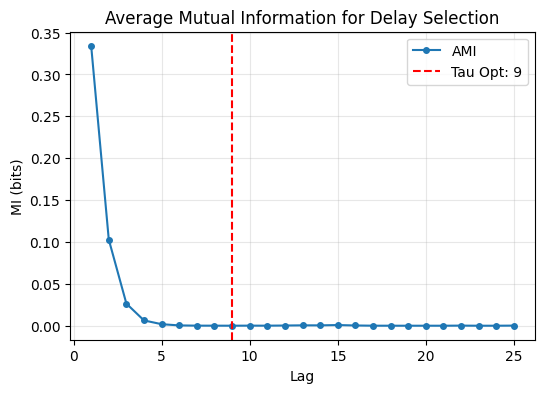


Results for AR:
  > Optimal m: 5


/Users/angelabortolato/Desktop/ITI_GroupProject/neuro_lib/diagnostics.py:80: RuntimeWarning: divide by zero encountered in divide
  is_fnn = (r_m1 / r_m > R_tol)


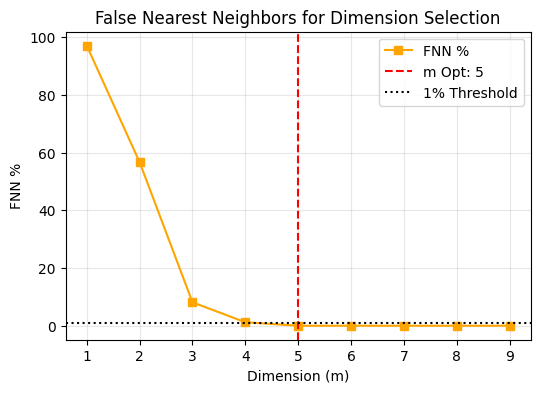

  [OK] Target (Y) is stationary (p-value: 0.0000e+00)
  > Source (X) Optimal Delay: 6
  > Target (Y) Optimal Delay: 9
  [Note] Large discrepancy in Tau between X and Y. Consider using separate embeddings.


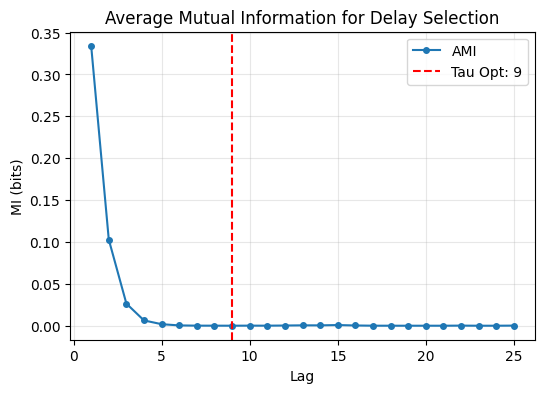


Results for AR:
  > Optimal m: 5


/Users/angelabortolato/Desktop/ITI_GroupProject/neuro_lib/diagnostics.py:80: RuntimeWarning: divide by zero encountered in divide
  is_fnn = (r_m1 / r_m > R_tol)


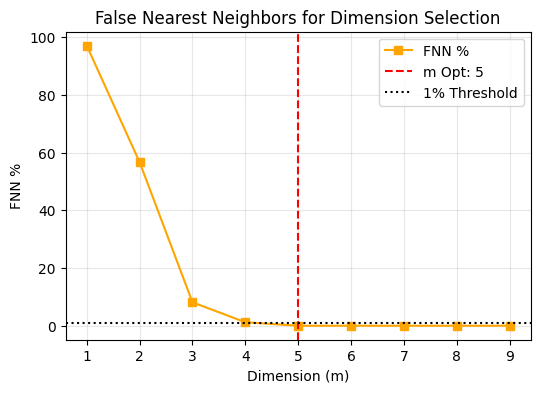

In [65]:
# We will store the results to use them later in the TE calculation
optimal_params = {}


print(f"\nChecking AR:")
    # Test Stationarity with ADF
    # Test both Source (X) and Target (Y)
for label, signal in [("Source (X)", x), ("Target (Y)", y)]:
    is_stationary, p_val = nl.check_stationarity(signal)
        
    if is_stationary:
        print(f"  [OK] {label} is stationary (p-value: {p_val:.4e})")
    else:
        # Throw a warning if p-value >= 0.05
        print(f"  [WARNING] {label} is NOT stationary (p-value: {p_val:.4e})")

    # Find embedding delay = the optimal spacing between embedded components such that there is no redundancy
    # Analyze Source (X), here use gc because faster
    tau_x, lags_x, mi_x = nl.find_optimal_delay(x,max_lag=25, method='gc')
    
    # Analyze Target (Y)
    tau_y, lags_y, mi_y = nl.find_optimal_delay(y,max_lag=25, method='gc')
    
    # Store results
    optimal_params = {'tau_x': tau_x, 'tau_y': tau_y}
    
    print(f"  > Source (X) Optimal Delay: {tau_x}")
    print(f"  > Target (Y) Optimal Delay: {tau_y}")
    
    # Check for discrepancy
    if abs(tau_x - tau_y) > 2:
        print(f"  [Note] Large discrepancy in Tau between X and Y. Consider using separate embeddings.")
    else:
        print(f"  [Note] Taus are similar. A unified embedding (Tau={tau_y}) is likely sufficient.")

    nl.plot_diagnostic_ami(lags_y, mi_y, tau_y)

    # Find embedding dimension m
    # Run FNN on Target (Y)
    m_opt, m_range, fnn_vals = nl.find_optimal_dimension(y, tau=optimal_params["tau_y"])
    
    print(f"\nResults for AR:")
    print(f"  > Optimal m: {m_opt}")
    
    # Plotting the result
    nl.plot_diagnostic_fnn(m_range, fnn_vals, m_opt)

    optimal_params = {
        'tau': tau_y,
        'm': m_opt,
    }




    well i obtain a larger m than expected for AR, this may be due to a high noise wrt signal

### Estimator Benchmarking (Lag Scanning)

In this phase, we perform a Lag Sweep to evaluate how accurately different TE estimators identify the pre-defined interaction delay. We use high SNR ($N=5000$, low noise) to establish an "ideal" baseline. We look for "consensus", so that different methods find same lag.

By construction we know the ground truth: Lag = 5

### Implementation Goals
1. Generate a "Latency Profile" for each method.
2. Identify which method is most robust to the non-linearities of the Oscillator model.
3. Compare the "sharpness" of the information peak across methods.

To ensure the estimators are not just detecting "shared information" (correlation) but truly "directional flow" (causality), we perform a symmetry test. 

We compare:
1. **True Direction ($X \rightarrow Y$):** Expect a significant peak at the ground-truth lag.
2. **Reverse Direction ($Y \rightarrow X$):** Expect values close to the noise floor, as $Y$ does not drive $X$ in our generative models.

**Success Criterion:** The Directedness Index ($DI = TE_{forward} - TE_{backward}$) should be significantly positive at the true lag.

Lag scanning AR


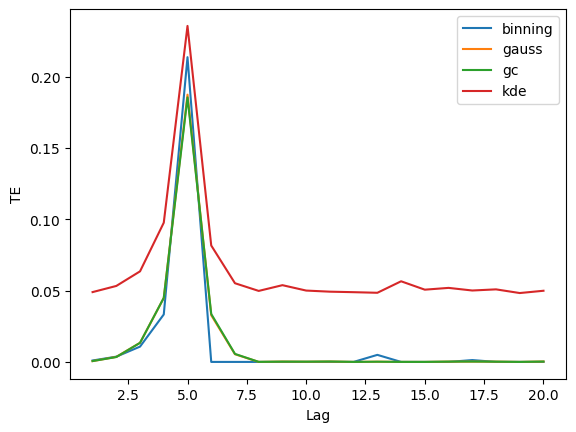

In [66]:
lags = range(1, 21)
methods = ['binning', 'gauss', 'gc', 'kde']
bins_to_test = np.arange(5, 30)

print("Lag scanning AR")
for mth in methods:
        m = optimal_params['m']
        m=1
        tau = optimal_params['tau']

        if mth == 'binning':
            te_profile = [nl.transfer_entropy_withMI(x, y, method=mth, lag=l, m=m, tau=tau, bins=bins_to_test) for l in lags]
        else:
            te_profile = [nl.transfer_entropy_withMI(x, y, method=mth, lag=l, m=m, tau=tau) for l in lags]
             
        plt.plot(lags, te_profile, label=mth)
        plt.xlabel("Lag")
        plt.ylabel("TE")
plt.legend()
plt.show()


For the AR model all methods correctly identify lag=5. kde (red) is broader and has a higher "baseline." This is because KDE is a "smoothing" estimator; it often overestimates information (positive bias) in small samples.


Running Symmetry Test for AR


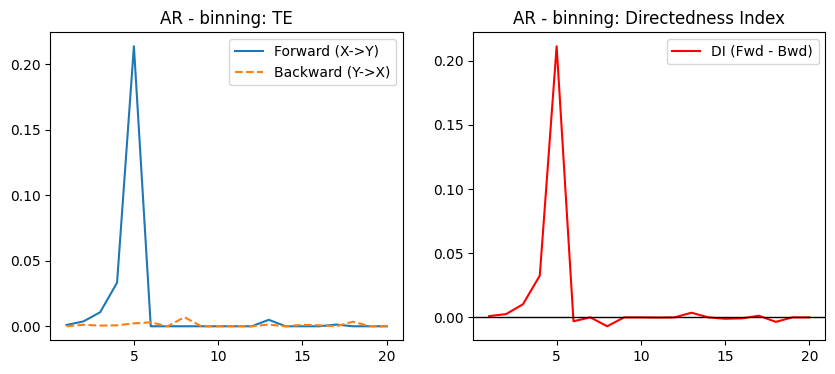

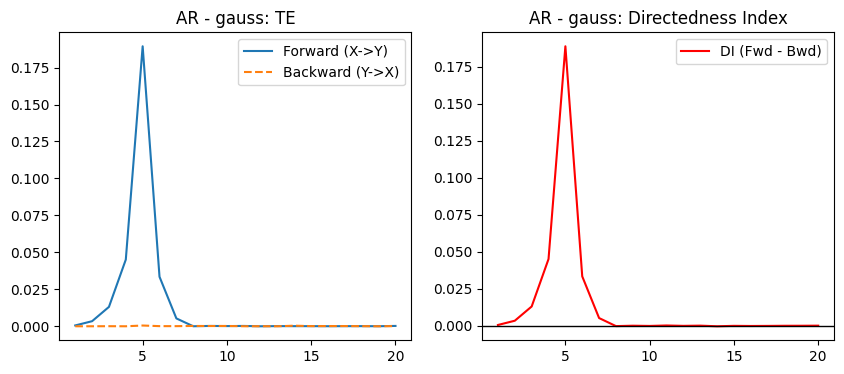

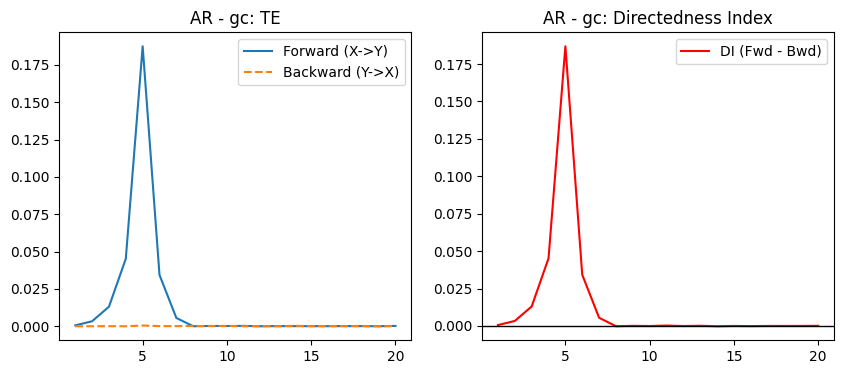

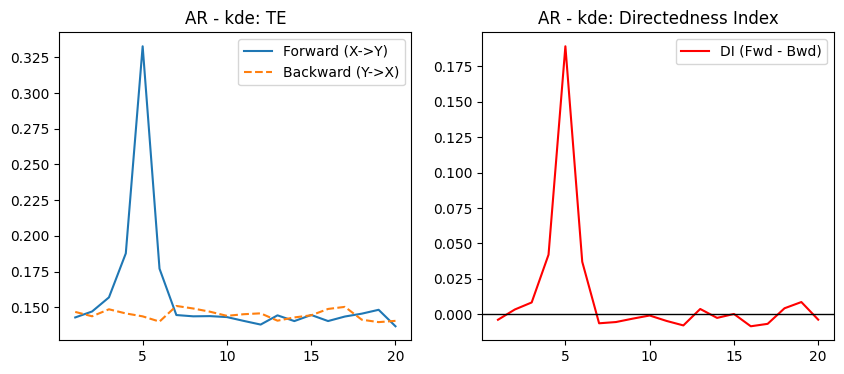

In [67]:
print(f"Running Symmetry Test for AR")
    
    # We will focus on one or two methods for clarity in the DI plot
for mth in ['binning', 'gauss', 'gc', 'kde']: 
        m = optimal_params['m']
        # Forcing m=1 only for binning to avoid curse of dimensionality
        m_eff = 1 if mth == 'binning' else m
        tau = optimal_params['tau']

        # 1. Forward Direction (X -> Y)
        if mth == 'binning':
            te_fwd = [nl.transfer_entropy_withMI(x, y, method=mth, lag=l, m=m_eff, tau=tau, bins=bins_to_test) for l in lags]
            te_bwd = [nl.transfer_entropy_withMI(y, x, method=mth, lag=l, m=m_eff, tau=tau, bins=bins_to_test) for l in lags]
        else:
            te_fwd = [nl.transfer_entropy_withMI(x, y, method=mth, lag=l, m=m_eff, tau=tau) for l in lags]
            te_bwd = [nl.transfer_entropy_withMI(y, x, method=mth, lag=l, m=m_eff, tau=tau) for l in lags]
        
        # Calculate Directedness Index
        di = np.array(te_fwd) - np.array(te_bwd)
        
        # Plotting
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(lags, te_fwd, label='Forward (X->Y)')
        plt.plot(lags, te_bwd, label='Backward (Y->X)', linestyle='--')
        plt.title(f"AR - {mth}: TE")
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(lags, di, color='red', label='DI (Fwd - Bwd)')
        plt.axhline(0, color='black', lw=1)
        plt.title(f"AR - {mth}: Directedness Index")
        plt.legend()
        plt.show()

For the AR Model, we actually have a mathematical ground truth! Since it is a linear Gaussian system, the TE is analytically related to the log-ratio of the conditional variances. If the only thing $Y$ can't explain about its own future is the noise $\epsilon$ and the influence of $X$, then:$$TE_{True} \approx \frac{1}{2} \log_2 \left( 1 + \frac{\text{Variance contributed by } X}{\sigma_{noise}^2} \right)$$

For an AR(1) process $X_t = \alpha X_{t-1} + \epsilon_x$, the stationary variance is:$$\text{Var}(X) = \frac{\sigma_x^2}{1 - \alpha^2}$$
Given parameters $\alpha$ and $\sigma_x$ from the stress-test generator. Then theoretical TE is:$$TE_{theory} = \frac{1}{2} \log_2 \left( 1 + \frac{\gamma^2 \cdot \text{Var}(X)}{\sigma_{y}^2} \right)$$

In [68]:
nl.theoretical_TE_AR(alpha, gamma, sigma_x, sigma_y)

np.float64(0.20751874963942188)


### Stress Test - Noise Robustness ($\sigma$ Sweep)
We evaluate the sensitivity of our estimators by increasing the standard deviation of the additive process noise ($\sigma$). As $\sigma$ increases, the "information signal" from $X$ becomes a smaller fraction of the total variance of $Y$.
The "Indistinguishability" Criterion
To determine when a peak disappears, we compare the True TE against a Shuffled Baseline (Null Hypothesis).
Null Hypothesis: We shuffle the source signal $X$ to break the temporal link with $Y$ and compute "Surrogate TE."Indistinguishable Point: When the True TE falls within the error bars of the Shuffled TE, the estimator has failed.

Implementation Goals
Regenerate signals with $\sigma \in [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]$. Calculate TE at the ground truth lag. Calculate "Shuffled TE" to provide a noise floor.

--- Sigma Noise Sweep ---


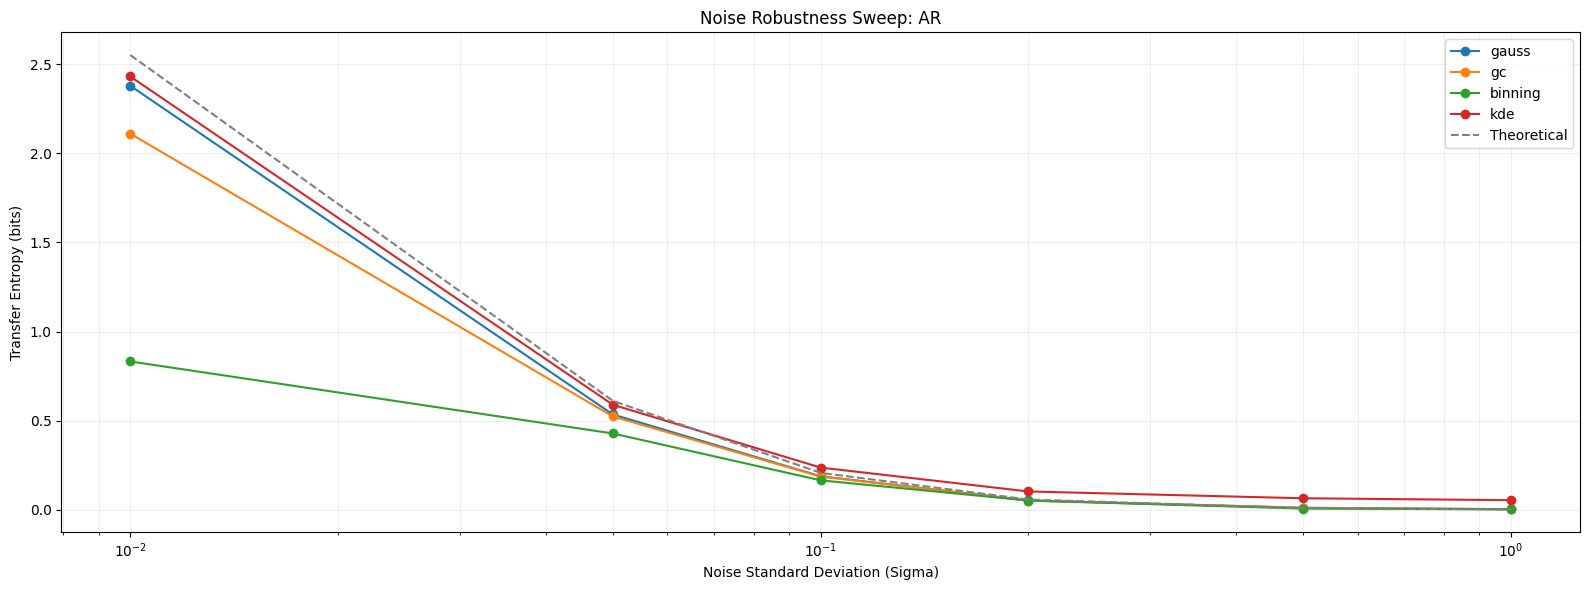

In [ ]:
# 1. Setup
N = 5000
sigmas = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
methods = ['gauss', 'gc', 'binning', 'kde']
bins_to_test = np.arange(5, 30)
results = []

print("--- Sigma Noise Sweep ---")


true_lag = 5 
#m_opt = optimal_params['m']
#tau_opt = optimal_params['tau']
m_opt=1
tau_opt=1
    
for s in sigmas:
        # REGENERATE the signal with specific sigma
        x_s, y_s = nl.generate_ar_coupled(N, alpha, beta, gamma, true_lag, sigma_x, sigma_y=s)
            
        for mth in methods:
            m_eff = 1 if mth == 'binning' else m_opt
            
            # Compute real TE
            if mth=="binning": te_real = nl.transfer_entropy_withMI(x_s, y_s, method=mth, lag=true_lag, 
                                                m=m_eff, tau=tau_opt, bins=bins_to_test)
            else: te_real = nl.transfer_entropy_withMI(x_s, y_s, method=mth, lag=true_lag, 
                                                m=m_eff, tau=tau_opt)
            results.append({
                'Dataset': 'AR',
                'Method': mth,
                'Sigma': s,
                'TE_Real': te_real
            })

te_theory_noise = [nl.theoretical_TE_AR(alpha, gamma, sigma_x, s) for s in sigmas]

df_noise = pd.DataFrame(results)

# 2. Plotting
fig, axes = plt.subplots(1, 1, figsize=(16, 6))


for mth in methods:
        subset = df_noise[(df_noise['Dataset'] == 'AR') & (df_noise['Method'] == mth)]
        plt.plot(subset['Sigma'], subset['TE_Real'], marker='o', label=f"{mth}")

plt.plot(sigmas, te_theory_noise, '--', color='grey', label='Theoretical')            
plt.title(f"Noise Robustness Sweep: AR")
plt.xlabel("Noise Standard Deviation (Sigma)")
plt.ylabel("Transfer Entropy (bits)")
plt.xscale('log') # Log scale helps see the drop-off
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

### Sample Sweep (N) - The Bias Check
In this phase, we fix the noise ($\sigma = 0.1$ is usually a good "realistic" middle ground) and vary the number of samples $N$.

The Goal: Observe "Bias Inflation." When $N$ is small, estimators (especially Binning and KDE) tend to "hallucinate" information. They see patterns in random noise simply because there aren't enough points to prove the patterns are accidental. As $N \to \infty$, the TE value should "deflate" and converge toward the true value.

--- Sample Sweep (N) ---
Processing N = 500...
Processing N = 1000...
Processing N = 2500...
Processing N = 5000...
Processing N = 10000...


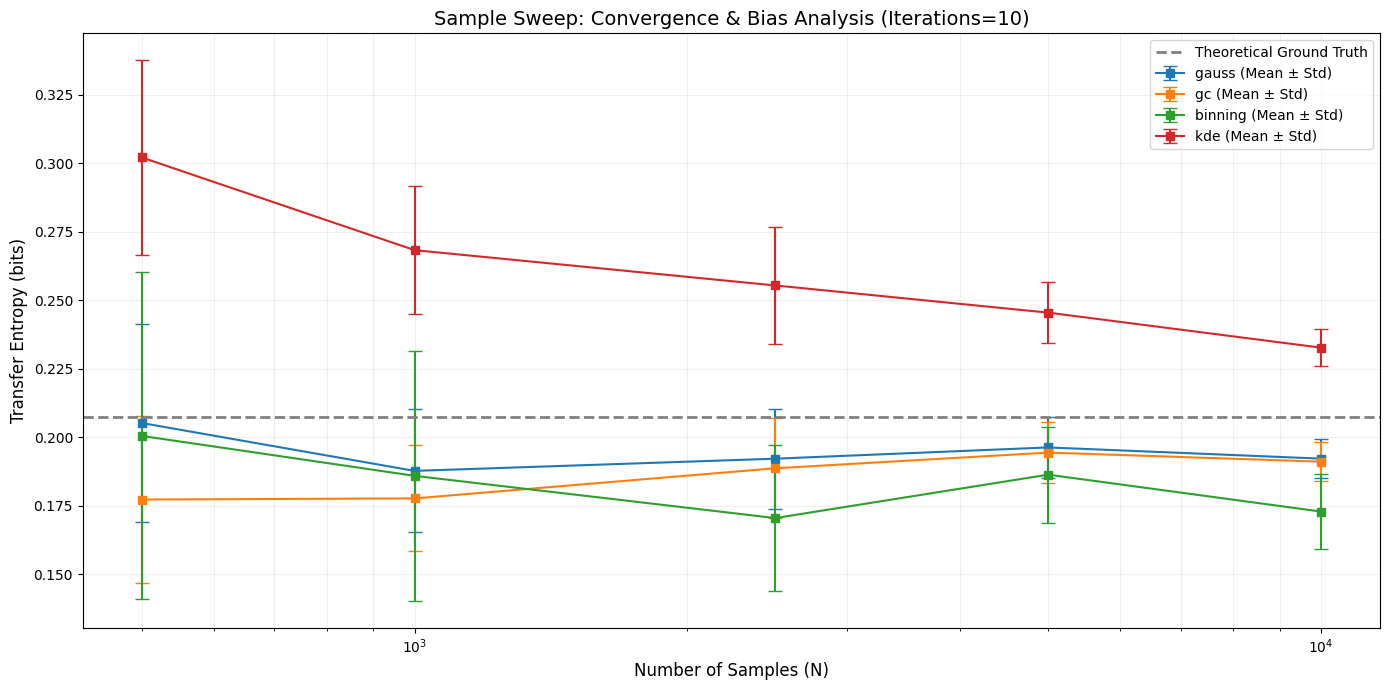

In [ ]:
n_samples = [500, 1000, 2500, 5000, 10000]
fixed_sigma = 0.1 
iterations = 10 # Number of times to repeat each N
raw_data = []
print("--- Sample Sweep (N) ---")
    
for n in n_samples:
    print(f"Processing N = {n}...")
    for i in range(iterations):        
        # Regenerate for each N to ensure independent realizations
        x_n, y_n = nl.generate_ar_coupled(n, alpha, beta, gamma, true_lag, fixed_sigma, fixed_sigma)

        for mth in methods:
            m_eff = 1 if mth == 'binning' else m_opt
            
            if mth == "binning": 
                te_val = nl.transfer_entropy_withMI(x_n, y_n method=mth, lag=true_lag, 
                                                   m=m_eff, tau=tau_opt, bins=bins_to_test)
            else: 
                te_val = nl.transfer_entropy_withMI(x_n, y_n, method=mth, lag=true_lag, 
                                                   m=m_eff, tau=tau_opt)
                 
            # Store every single run
            raw_data.append({'Method': mth, 'N': n, 'TE': te_val})

te_theory=nl.theoretical_TE_AR(alpha, gamma, sigma_x, sigma_y)

# Convert to DataFrame
df_raw = pd.DataFrame(raw_data)

# Calculate Mean and Standard Deviation for each group
df_stats = df_raw.groupby(['Method', 'N'])['TE'].agg(['mean', 'std']).reset_index()

# --- Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

for mth in methods:
    subset = df_stats[df_stats['Method'] == mth]
    
    # Use errorbar to show the variation across iterations
    ax.errorbar(subset['N'], subset['mean'], yerr=subset['std'], 
                marker='s', capsize=5, label=f"{mth} (Mean ± Std)")

ax.axhline(y=te_theory, color='grey', linestyle='--', linewidth=2, label='Theoretical Ground Truth')

ax.set_title(f"Sample Sweep: Convergence & Bias Analysis (Iterations={iterations})", fontsize=14)
ax.set_xlabel("Number of Samples (N)", fontsize=12)
ax.set_ylabel("Transfer Entropy (bits)", fontsize=12)
ax.set_xscale('log') # Log scale makes the convergence easier to see
ax.grid(True, which="both", ls="-", alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

Notice that the KDE method remains significantly above the Theoretical Ground Truth even at $N=10^4$. Non-parametric density estimators like KDE struggle with the "Curse of Dimensionality." Even in this simple case, the bandwidth selection tends to "overfit" the data, seeing more information than actually exists.

### Statistical Validation via Permutation Testing
Beyond simply estimating a value, we must determine if the observed Transfer Entropy ($TE$) represents a genuine causal link or merely a stochastic artifact. Because information-theoretic estimators often exhibit a positive bias—yielding non-zero values even for independent signals—we employ a Permutation Test to establish a rigorous confidence threshold.

This non-parametric approach generates a Null Distribution by repeatedly shuffling the source signal $X$ while keeping the target $Y$ intact. This process preserves the individual statistical properties (mean, variance, distribution) of the signals but systematically destroys the temporal dependency and directed information flow between them.

By comparing our original $TE_{real}$ against this surrogate distribution, we calculate a p-value. This represents the probability that a value as extreme as our estimate could have occurred by chance. A result is deemed statistically significant only if it exceeds the $95^{th}$ percentile of the null distribution ($p < 0.05$), effectively separating true biological or physical interaction from methodological noise.

--- Systematic Significance Benchmark ---

  Method  TE_Real  P_Value  95th_Threshold  Significant
  gauss 0.203451 0.009901        0.000261         True
     gc 0.202469 0.009901        0.000276         True
binning 0.189744 0.009901        0.001709         True
    kde 0.243852 0.009901        0.042155         True


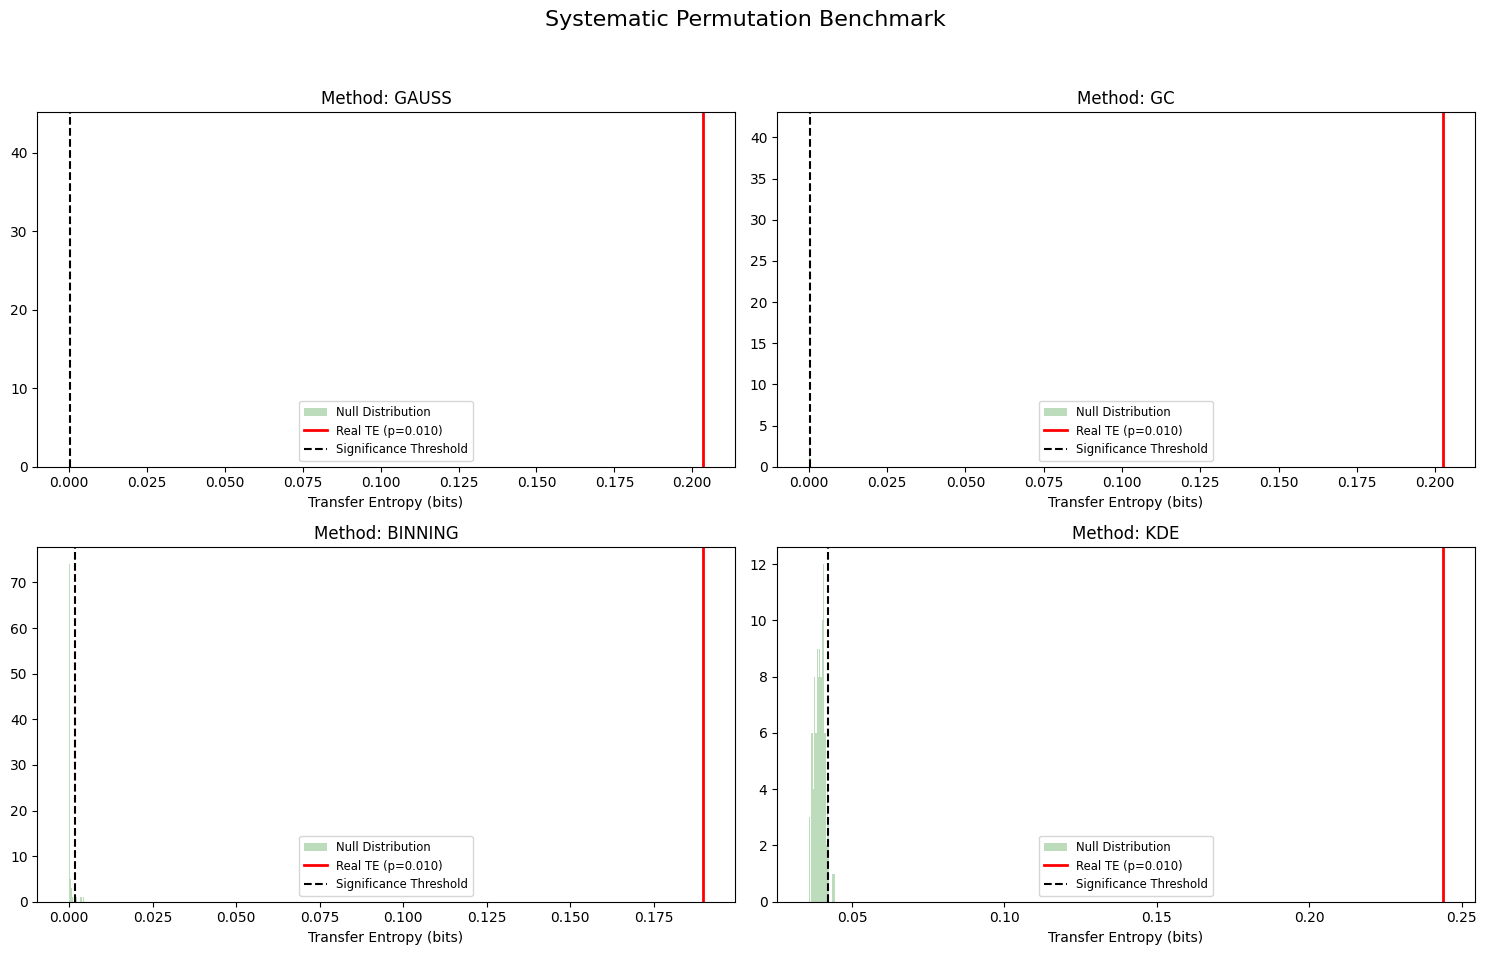

In [87]:
n_perms = 100
stat_summary = []
all_distributions = {}

print(f"--- Systematic Significance Benchmark ---")

for mth in methods:
    # Handle method-specific parameters
    m_eff = 1 if mth == 'binning' else m_opt
    
    # Run Significance Wrapper
    if mth == "binning": 
        te, p, thr, dist = nl.test_significance(x, y, mth, true_lag, m_eff, tau_opt, n_perms=n_perms, bins=bins_to_test)
    else: 
        te, p, thr, dist = nl.test_significance(x, y, mth, true_lag, m_eff, tau_opt, n_perms=n_perms)

    
    # Store for summary table
    stat_summary.append({
        'Method': mth,
        'TE_Real': te,
        'P_Value': p,
        '95th_Threshold': thr,
        'Significant': p < 0.05
    })
    all_distributions[mth] = dist

# 2. Display results as a Table
df_stat = pd.DataFrame(stat_summary)
print("\n", df_stat.to_string(index=False))

# 3. Comparative Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, mth in enumerate(methods):
    dist = all_distributions[mth]
    real_te = df_stat.loc[df_stat['Method'] == mth, 'TE_Real'].values[0]
    thr = df_stat.loc[df_stat['Method'] == mth, '95th_Threshold'].values[0]
    p_val = df_stat.loc[df_stat['Method'] == mth, 'P_Value'].values[0]
    
    axes[i].hist(dist, bins=20, alpha=0.3, color='forestgreen', label='Null Distribution')
    axes[i].axvline(real_te, color='red', lw=2, label=f"Real TE (p={p_val:.3f})")
    axes[i].axvline(thr, color='black', ls='--', label='Significance Threshold')
    
    axes[i].set_title(f"Method: {mth.upper()}")
    axes[i].set_xlabel("Transfer Entropy (bits)")
    axes[i].legend(fontsize='small')

plt.suptitle(f"Systematic Permutation Benchmark", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Systematic Synthesis and Performance Mapping
The final stage of our methodological validation involves a comprehensive Stress Map. By cross-referencing signal length ($N$) and noise intensity ($\sigma$), we can define the operational boundaries for each estimator. This phase provides the "User Manual" for the library, indicating which method is most reliable under specific data constraints.

To compare methods of different mathematical natures, we utilize two primary metrics:
- Absolute Relative Error (ARE): Measures the precision of the estimate compared to the analytical ground truth.$$\text{ARE} = \frac{|TE_{estimated} - TE_{theoretical}|}{TE_{theoretical}}$$
- Significance Mask: A binary filter derived from the Phase 5 Permutation Test. This identifies "False Positives" where an estimator might return a high value that is not statistically distinguishable from random noise.

--- Starting Iterative Sweep (20 configs x 10 iterations) ---

[1/20] Testing N=500, Sigma=0.05 | True TE: 0.6112

[2/20] Testing N=500, Sigma=0.1 | True TE: 0.2075

[3/20] Testing N=500, Sigma=0.2 | True TE: 0.0577

[4/20] Testing N=500, Sigma=0.5 | True TE: 0.0096

[5/20] Testing N=500, Sigma=1.0 | True TE: 0.0024

[6/20] Testing N=1000, Sigma=0.05 | True TE: 0.6112

[7/20] Testing N=1000, Sigma=0.1 | True TE: 0.2075

[8/20] Testing N=1000, Sigma=0.2 | True TE: 0.0577

[9/20] Testing N=1000, Sigma=0.5 | True TE: 0.0096

[10/20] Testing N=1000, Sigma=1.0 | True TE: 0.0024

[11/20] Testing N=2500, Sigma=0.05 | True TE: 0.6112

[12/20] Testing N=2500, Sigma=0.1 | True TE: 0.2075

[13/20] Testing N=2500, Sigma=0.2 | True TE: 0.0577

[14/20] Testing N=2500, Sigma=0.5 | True TE: 0.0096

[15/20] Testing N=2500, Sigma=1.0 | True TE: 0.0024

[16/20] Testing N=5000, Sigma=0.05 | True TE: 0.6112

[17/20] Testing N=5000, Sigma=0.1 | True TE: 0.2075

[18/20] Testing N=5000, Sigma=0.2 | True TE: 0

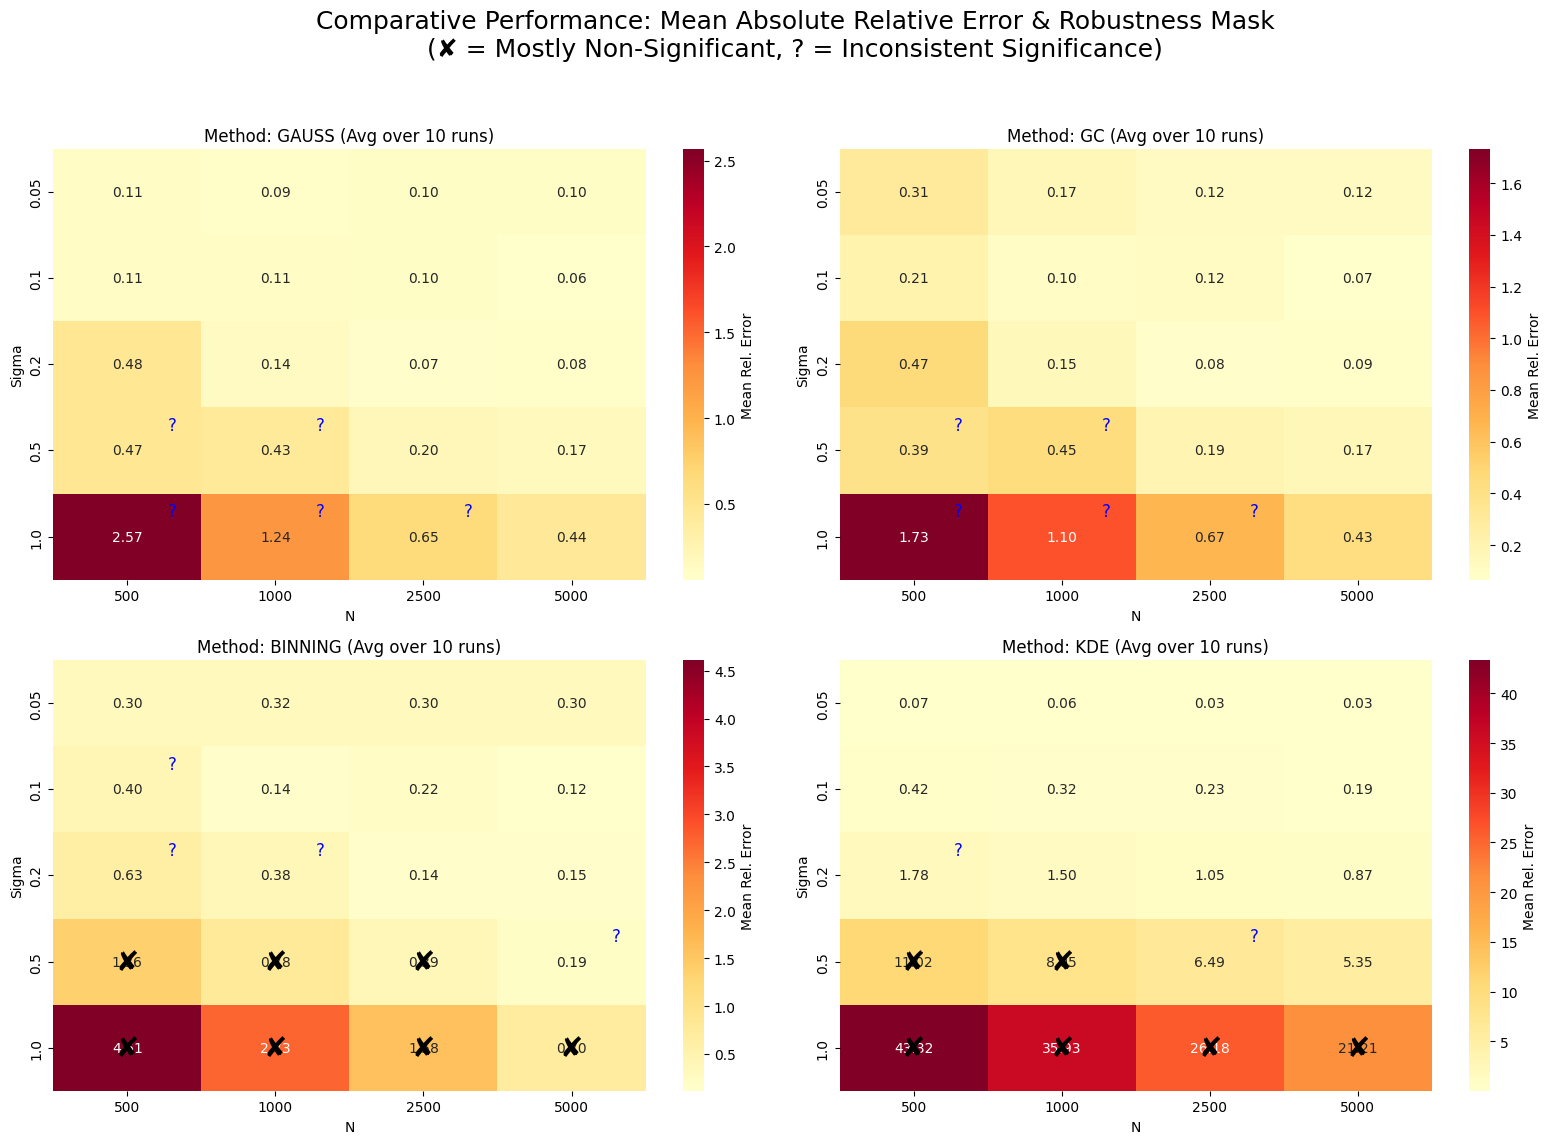

In [96]:
# 1. Settings
n_list = [500, 1000, 2500, 5000]
sigma_list = [0.05, 0.1, 0.2, 0.5, 1.0]
n_perms = 50       # Reduced perms slightly to compensate for more iterations
n_iterations = 10  # Number of independent realizations per cell
results_raw = []

total_configs = len(n_list) * len(sigma_list)
step_counter = 0

print(f"--- Starting Iterative Sweep ({total_configs} configs x {n_iterations} iterations) ---")
start_total = time.time()

for n in n_list:
    for s in sigma_list:
        step_counter += 1
        te_true = nl.theoretical_TE_AR(alpha, gamma, sigma_x, s)
        print(f"\n[{step_counter}/{total_configs}] Testing N={n}, Sigma={s} | True TE: {te_true:.4f}")
        
        for i in range(n_iterations):
            # Generate a NEW independent realization for every iteration
            x, y = nl.generate_ar_coupled(n, alpha, beta, gamma, true_lag, sigma_x, s)
            
            for mth in methods:
                m_eff = 1 if mth == 'binning' else m_opt
                
                # Run Significance Test
                if mth == 'binning':
                    te_est, p_val, _, _ = nl.test_significance(x, y, mth, true_lag, m_eff, tau_opt, n_perms=n_perms, bins=bins_to_test)
                else:
                    te_est, p_val, _, _ = nl.test_significance(x, y, mth, true_lag, m_eff, tau_opt, n_perms=n_perms)

                rel_error = np.abs(te_est - te_true) / te_true
                is_sig = 1 if p_val < 0.05 else 0

                results_raw.append({
                    'Method': mth, 'N': n, 'Sigma': s, 
                    'RelError': rel_error, 'Significant': is_sig
                })

# 2. Data Aggregation
df_raw = pd.DataFrame(results_raw)

# Group to get mean error and significance probability
df_map = df_raw.groupby(['Method', 'Sigma', 'N']).agg({
    'RelError': 'mean', 
    'Significant': 'mean'  # This gives a value between 0 and 1
}).reset_index()

print(f"\n--- Sweep Completed in {(time.time() - start_total)/60:.2f} minutes ---")

# 3. Plotting Heatmaps
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, mth in enumerate(methods):
    subset = df_map[df_map['Method'] == mth]
    pivot_error = subset.pivot(index="Sigma", columns="N", values="RelError")
    pivot_sig_prob = subset.pivot(index="Sigma", columns="N", values="Significant")
    
    sns.heatmap(pivot_error, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[i], cbar_kws={'label': 'Mean Rel. Error'})
    
    # Logic for ✘: Mask if the method failed to be significant in at least 50% of the runs
    for y_idx, s in enumerate(sigma_list):
        for x_idx, n in enumerate(n_list):
            sig_prob = pivot_sig_prob.iloc[y_idx, x_idx]
            if sig_prob < 0.5: # Failed more often than it succeeded
                axes[i].text(x_idx + 0.5, y_idx + 0.5, '✘', ha='center', va='center', color='black', fontsize=20)
            elif sig_prob < 1.0: # Inconsistent (Significant some times, not others)
                axes[i].text(x_idx + 0.8, y_idx + 0.2, '?', ha='center', va='center', color='blue', fontsize=12)

    axes[i].set_title(f"Method: {mth.upper()} (Avg over {n_iterations} runs)")

plt.suptitle("Comparative Performance: Mean Absolute Relative Error & Robustness Mask\n(✘ = Mostly Non-Significant, ? = Inconsistent Significance)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()